In [103]:
words=open("names.csv",encoding="utf-8").read().splitlines()

In [104]:
import re
import torch
import torch.nn.functional as F

clean_words = []

for w in words:

    w = re.sub(r"[^A-Za-z\s'& -]", "", w)
    w = " ".join(w.split())
    if w:
        clean_words.append(w)

words = clean_words
words[:8]

['lavera',
 'fairytabs',
 'arkive',
 'gaa',
 'cultiv cosmetique',
 'the green recipe',
 'mlanine',
 'base cosmetics']

In [105]:
chars=sorted(list(set(''.join(words))))
stoi={s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos={i:s for s,i in stoi.items()}
print(itos)

{1: ' ', 2: '&', 3: "'", 4: '-', 5: 'a', 6: 'b', 7: 'c', 8: 'd', 9: 'e', 10: 'f', 11: 'g', 12: 'h', 13: 'i', 14: 'j', 15: 'k', 16: 'l', 17: 'm', 18: 'n', 19: 'o', 20: 'p', 21: 'q', 22: 'r', 23: 's', 24: 't', 25: 'u', 26: 'v', 27: 'w', 28: 'x', 29: 'y', 30: 'z', 0: '.'}


In [106]:
#dataset creation

X,Y=[],[]
block_size=3 #context length i.e how many char to know to predict next one

for w in words:
    # print(w)
    context=[0]*block_size
    for ch in w+'.':
        ix=stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context),'--->',itos[ix])
        context=context[1:]+[ix]

X=torch.tensor(X)
Y=torch.tensor(Y)
        


In [107]:
 #lookup table
C=torch.randn((31,2))
C[:5]

tensor([[-0.6799, -0.0971],
        [-0.5221,  3.1480],
        [-0.8766, -0.1771],
        [-0.2619,  0.7079],
        [ 1.1477,  0.7279]])

In [108]:
emb=C[X]
emb[1]

tensor([[-0.6799, -0.0971],
        [-0.6799, -0.0971],
        [ 1.9115, -0.6420]])

In [109]:
emb.size()

torch.Size([651987, 3, 2])

In [110]:
torch.cat([emb[:,0,:],emb[:,1,:],emb[:,2,:]],1) #have to change is context len chnages therfore we use unbind

tensor([[-0.6799, -0.0971, -0.6799, -0.0971, -0.6799, -0.0971],
        [-0.6799, -0.0971, -0.6799, -0.0971,  1.9115, -0.6420],
        [-0.6799, -0.0971,  1.9115, -0.6420, -0.1616,  0.4263],
        ...,
        [ 0.2740, -1.6352, -1.2837, -0.2590,  0.6635,  0.1189],
        [-1.2837, -0.2590,  0.6635,  0.1189,  0.1335,  1.4585],
        [ 0.6635,  0.1189,  0.1335,  1.4585, -1.1837,  0.9680]])

In [111]:
torch.cat(torch.unbind(emb,1),1) # even though unbind creates a view but cat copies and allocate new memomry therefore we switch to view

tensor([[-0.6799, -0.0971, -0.6799, -0.0971, -0.6799, -0.0971],
        [-0.6799, -0.0971, -0.6799, -0.0971,  1.9115, -0.6420],
        [-0.6799, -0.0971,  1.9115, -0.6420, -0.1616,  0.4263],
        ...,
        [ 0.2740, -1.6352, -1.2837, -0.2590,  0.6635,  0.1189],
        [-1.2837, -0.2590,  0.6635,  0.1189,  0.1335,  1.4585],
        [ 0.6635,  0.1189,  0.1335,  1.4585, -1.1837,  0.9680]])

In [112]:
W1=torch.randn((6,100))
b1=torch.randn(100)

In [113]:

h=torch.tanh(emb.view(-1,6)@W1+b1) #check broadcasting rules
h

tensor([[-0.9256, -0.0024, -0.8157,  ..., -0.9377, -0.8721,  0.9909],
        [ 0.6411,  0.8930, -0.6791,  ..., -0.9826,  0.8624,  0.9982],
        [ 0.9741, -0.6783, -0.9912,  ..., -0.9508, -0.9999,  0.9137],
        ...,
        [-0.9799, -0.1934, -0.9693,  ..., -0.9449,  0.5903,  0.9979],
        [ 0.7488,  0.9896, -0.9983,  ..., -0.9998, -0.9982,  0.8845],
        [-1.0000, -0.7651, -0.9309,  ..., -0.9906, -0.9789,  0.9565]])

In [114]:
#last layer
W2=torch.randn((100,31))
b2=torch.randn(31)

In [115]:
logits=h@W2+b2
counts=logits.exp()
probs=counts/counts.sum(1,keepdims=True)

In [116]:
probs

tensor([[1.5008e-08, 1.2798e-01, 3.7153e-09,  ..., 2.3514e-06, 1.2241e-02,
         1.7896e-07],
        [1.9056e-08, 7.7544e-12, 2.7833e-10,  ..., 6.0124e-13, 7.1194e-01,
         5.4178e-09],
        [5.0877e-05, 9.5854e-04, 1.9563e-03,  ..., 2.1547e-12, 3.3640e-01,
         4.4958e-08],
        ...,
        [1.7861e-14, 4.9435e-05, 1.5243e-09,  ..., 3.9203e-15, 1.3474e-02,
         5.8240e-07],
        [7.8066e-08, 1.0435e-04, 3.0570e-02,  ..., 1.9439e-09, 3.6021e-01,
         2.7720e-07],
        [4.5795e-12, 9.9918e-01, 1.3362e-04,  ..., 1.7653e-05, 2.5978e-15,
         9.0142e-14]])

# working 

In [117]:
X.shape
Y.shape

torch.Size([651987])

In [118]:
g=torch.Generator().manual_seed(2147483764)
C=torch.randn((31,2),generator=g)
W1=torch.randn((6,100),generator=g)
b1=torch.randn(100,generator=g)
W2=torch.randn((100,31),generator=g)
b2=torch.randn(31,generator=g)
parameters=[C,W1,b1,W2,b2]



In [119]:
for p in parameters:
    p.requires_grad=True

In [120]:
lre=torch.linspace(-3,0,1000)
lrs=10**lre

In [121]:
lri=[]
lossi=[]

for i in range(1000):

    #minibatch 
    ix=torch.randint(0,X.shape[0],(32,))

    #forward pass
    emb=C[X[ix]]
    h=torch.tanh(emb.view(-1,6)@W1+b1)
    logits=h@W2+b2
    loss=F.cross_entropy(logits,Y[ix]) #doesn't assign intermediate variables space
    # print(loss.item())

    #backward pass
    for p in parameters:
        p.grad=None
    loss.backward()

    lr=lrs[i]

    #update
    for p in parameters:
        p.data+=-lr*p.grad

    #track stats
    lri.append(lre[i])
    lossi.append(loss.item())
# print(loss.item())

    

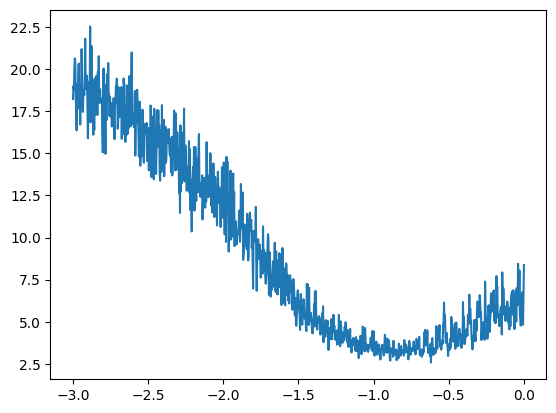

In [ ]:
import matplotlib.pyplot as plt
%matplogittlib inline
plt.plot(lri,lossi)

best lr is 10^-1 i.e 0.1
